✅ BASE_DIR   : /Users/pravallikachepuri/customer-churn-prediction
✅ DATA_DIR   : /Users/pravallikachepuri/customer-churn-prediction/data
✅ RESULTS_DIR: /Users/pravallikachepuri/customer-churn-prediction/results
✅ MODELS_DIR : /Users/pravallikachepuri/customer-churn-prediction/models

📌 Shape      : (7043, 21)
📌 Columns    : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

📌 Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0


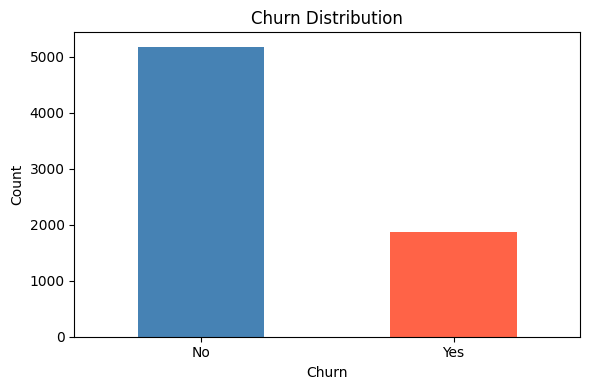


📌 Churn Rate:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


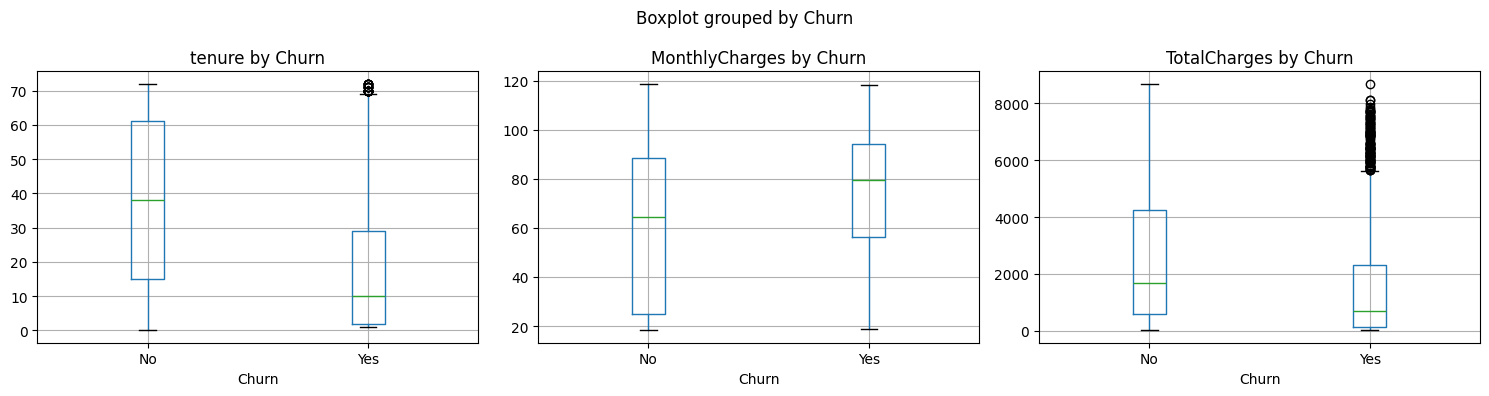

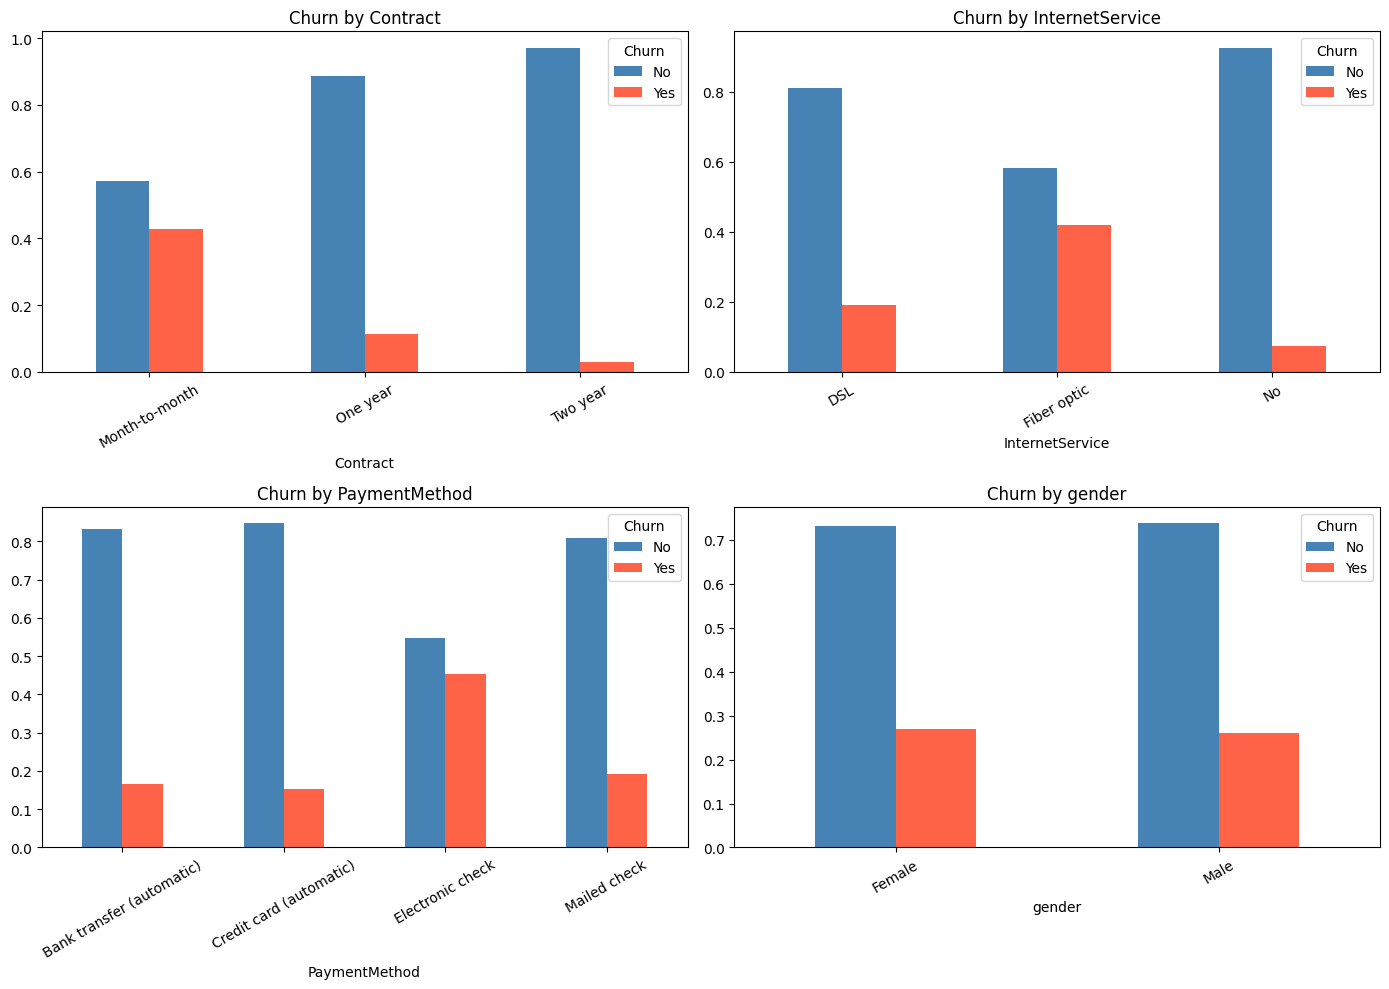


✅ EDA Complete!
📁 Charts saved to: /Users/pravallikachepuri/customer-churn-prediction/results


In [6]:
# ============================================================
# 📊 NOTEBOOK 1 — Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Setup Paths ──────────────────────────────────────────────
BASE_DIR    = os.path.expanduser('~/customer-churn-prediction')
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print("✅ BASE_DIR   :", BASE_DIR)
print("✅ DATA_DIR   :", DATA_DIR)
print("✅ RESULTS_DIR:", RESULTS_DIR)
print("✅ MODELS_DIR :", MODELS_DIR)

# ── Load Data ────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

print("\n📌 Shape      :", df.shape)
print("📌 Columns    :", df.columns.tolist())
print("\n📌 Missing Values:\n", df.isnull().sum())
print("\n📌 Data Types:\n",     df.dtypes)

# ── Churn Distribution ───────────────────────────────────────
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'churn_distribution.png'))
plt.show()

churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"\n📌 Churn Rate:\n{churn_rate}")

# ── Fix TotalCharges type ────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ── Numerical Features vs Churn ──────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'numerical_vs_churn.png'))
plt.show()

# ── Categorical Features vs Churn ────────────────────────────
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cat_cols):
    ax = axes[i//2][i%2]
    churn_pct = df.groupby(col)['Churn'].value_counts(
                    normalize=True).unstack()
    churn_pct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(f'Churn by {col}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'categorical_vs_churn.png'))
plt.show()

print("\n✅ EDA Complete!")
print(f"📁 Charts saved to: {RESULTS_DIR}")